# 04. Modeling and Hyperparameter Tuning

**Course:** CSE437 Data Science
**Group:** 10
**Project:** Predicting Google Play Store App Ratings Using Machine Learning

**Purpose of this notebook.** Using the engineered features from
`03_feature_engineering.ipynb`, this notebook:

1. Declares the **primary metric before any results are produced.**
2. Builds a `DummyRegressor` baseline.
3. Builds two model families — **Ridge Regression** and **RandomForestRegressor**
   — each inside a leakage-safe `sklearn` `Pipeline`.
4. Uses cross-validation exclusively for model development and hyperparameter
   tuning. **The test set is touched exactly once, in Section 9, and nowhere
   else in this notebook.**
5. Reports the full search space, number of candidates, folds, scoring function,
   best configuration, validation scores, and tuning trends for both models
   (report Section 6 material).

The faculty's expected R² range for this task is **0.05–0.15**, because app
metadata carries only weak signal for a subjective quantity like `Rating`. This
notebook reports whatever the cross-validated numbers actually are — it does not
adjust features, folds, or hyperparameter ranges in order to push R² higher.


## 0. Imports and Reproducibility Setup

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FEATURES_PATH = "../data/processed/googleplaystore_features.csv"
SPLIT_PATH = "../data/processed/train_test_split.csv"
PROCESSED_DIR = "../data/processed"
FIGURES_DIR = "../figures"
MODELS_DIR = "../models"
for d in [PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Random seed fixed at:", RANDOM_STATE)


Random seed fixed at: 42


## 1. Load Engineered Features and Reconstruct the Train/Test Split

The exact train/test partition produced in `03_feature_engineering.ipynb`
(`data/processed/train_test_split.csv`, `random_state=42`) is reloaded here rather
than re-run, so the split used for modelling is identical to the one already
diagnosed in notebook 03.


In [2]:
df = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

numeric_features = ["log_reviews", "log_installs", "Size_MB", "Price_USD", "is_paid", "days_since_update"]
categorical_features = ["Category", "Content Rating"]
feature_columns = numeric_features + categorical_features
target = "Rating"

train_idx = split.loc[split["split"] == "train", "row_index"].values
test_idx = split.loc[split["split"] == "test", "row_index"].values

X_train = df.loc[train_idx, feature_columns]
X_test = df.loc[test_idx, feature_columns]
y_train = df.loc[train_idx, target]
y_test = df.loc[test_idx, target]

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")
print(f"Train target mean: {y_train.mean():.4f}   Test target mean: {y_test.mean():.4f}")
print()
print("REMINDER: the test set (X_test, y_test) is not touched again until Section 9.")


Train: 6556 rows   Test: 1640 rows
Train target mean: 4.1736   Test target mean: 4.1720

REMINDER: the test set (X_test, y_test) is not touched again until Section 9.


## 2. Primary Metric — Declared Before Any Results

Three metrics are reported throughout this notebook: **R² (coefficient of
determination), MAE (mean absolute error), and RMSE (root mean squared error)**.

**Primary metric: R².** This is declared now, before any model is fit or any
score is seen, for two reasons: (1) it is the metric the faculty's expected
range (0.05–0.15) is stated in terms of, and (2) it directly answers research
question 2 ("how accurately can models predict Rating") in a scale-free way that
is comparable across model families. MAE and RMSE are reported as secondary
metrics because they are more interpretable in the original unit of the target
(rating points on a 1–5 scale), which matters for judging whether a given R² is
practically meaningful.

All hyperparameter tuning below (`scoring="r2"`) optimises the primary metric
directly.


In [3]:
PRIMARY_METRIC = "r2"
SCORING = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error",
}
print("Primary metric fixed as:", PRIMARY_METRIC)


Primary metric fixed as: r2


## 3. Leakage-Safe Preprocessing Pipelines

Two `ColumnTransformer` variants are built, reused throughout:

- **Scaled** (median imputation + `StandardScaler` for numeric, most-frequent
  imputation + `OneHotEncoder` for categorical) — for **Ridge**, which is
  sensitive to feature scale.
- **Unscaled** (median imputation only for numeric, same categorical branch) —
  for **RandomForestRegressor**, which is invariant to monotonic feature scaling
  and does not need it.

Both are embedded inside `sklearn.Pipeline` objects together with their model, so
that every call to `cross_validate`/`GridSearchCV`/`RandomizedSearchCV` refits
imputation, scaling, and encoding **independently on each fold's training portion
only** — no statistic ever leaks from a validation fold into its own training.


In [4]:
numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_pipeline_unscaled, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("5-fold CV strategy fixed, random_state=42, shuffled.")


5-fold CV strategy fixed, random_state=42, shuffled.


## 4. Feature Representation — Full Space vs. PCA vs. Feature Selection

`03_feature_engineering.ipynb` deferred the decision of whether to keep PCA (or
the `f_regression` feature-selection subset) in the final modelling pipeline,
pending an empirical comparison. That comparison is run here, **via
cross-validation on the training set only**, before any hyperparameter tuning, so
that the choice of feature representation itself is evidence-based.


In [5]:
ridge_full = Pipeline([("prep", preprocessor_scaled), ("model", Ridge(random_state=RANDOM_STATE))])
ridge_pca = Pipeline([("prep", preprocessor_scaled),
                       ("pca", PCA(n_components=9, random_state=RANDOM_STATE)),
                       ("model", Ridge(random_state=RANDOM_STATE))])
ridge_selectk = Pipeline([("prep", preprocessor_scaled),
                           ("select", SelectKBest(score_func=f_regression, k=22)),
                           ("model", Ridge(random_state=RANDOM_STATE))])

rf_full = Pipeline([("prep", preprocessor_scaled),
                     ("model", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=1))])
rf_pca = Pipeline([("prep", preprocessor_scaled),
                    ("pca", PCA(n_components=9, random_state=RANDOM_STATE)),
                    ("model", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=1))])

representation_candidates = {
    ("Ridge", "Full feature space (45 dims)"): ridge_full,
    ("Ridge", "PCA (9 components, ~90% variance)"): ridge_pca,
    ("Ridge", "SelectKBest f_regression (22 features)"): ridge_selectk,
    ("RandomForest", "Full feature space (45 dims)"): rf_full,
    ("RandomForest", "PCA (9 components, ~90% variance)"): rf_pca,
}

rep_results = []
for (model_name, rep_name), pipe in representation_candidates.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring="r2")
    rep_results.append({
        "model": model_name,
        "representation": rep_name,
        "cv_r2_mean": res["test_score"].mean(),
        "cv_r2_std": res["test_score"].std(),
    })

representation_comparison = pd.DataFrame(rep_results).sort_values(["model", "cv_r2_mean"], ascending=[True, False])
representation_comparison.to_csv(f"{PROCESSED_DIR}/representation_comparison_cv.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/representation_comparison_cv.csv")
representation_comparison


Saved: ../data/processed/representation_comparison_cv.csv


,model,representation,cv_r2_mean,cv_r2_std
3,RandomForest,Full feature space (45 dims),0.130425,0.031939
4,RandomForest,"PCA (9 components, ~90% variance)",0.096467,0.022653
0,Ridge,Full feature space (45 dims),0.147140,0.013926
2,Ridge,SelectKBest f_regression (22 features),0.143678,0.012626
1,Ridge,"PCA (9 components, ~90% variance)",0.048175,0.006302


**Decision (evidence-based, made here — not assumed in advance).** For both
model families, the **full engineered feature space outperforms both the
PCA-reduced representation and the `f_regression`-selected subset** on
cross-validated R². PCA in particular reduces R² substantially for Ridge
(compressing 45 dimensions to 9 principal components discards enough
category-specific signal — several individual `Category` dummies scored
significant in notebook 03's `f_regression` pass — that predictive power drops).
`SelectKBest` performs close to, but not above, the full space.

**PCA is therefore not retained in the final modelling pipeline.** No feature
selection subset is applied either, since it shows no measurable benefit over the
full space. This matches the faculty instruction not to claim a PCA benefit
without evidence — the evidence here points the other way. All hyperparameter
tuning below uses the **full engineered feature space**.


## 5. Baseline — `DummyRegressor`

A trivial baseline that always predicts the training-set mean `Rating`,
regardless of input features. Any model family must beat this to demonstrate it
is using the features at all.


In [6]:
dummy_model = DummyRegressor(strategy="mean")
dummy_cv = cross_validate(dummy_model, X_train, y_train, cv=cv, scoring=SCORING)

dummy_summary = {
    "model": "Dummy (mean)",
    "cv_r2_mean": dummy_cv["test_r2"].mean(),
    "cv_r2_std": dummy_cv["test_r2"].std(),
    "cv_mae_mean": -dummy_cv["test_neg_mae"].mean(),
    "cv_rmse_mean": -dummy_cv["test_neg_rmse"].mean(),
}
print("Baseline (DummyRegressor, predicts training mean) — 5-fold CV:")
for k, v in dummy_summary.items():
    print(f"  {k}: {v}")


Baseline (DummyRegressor, predicts training mean) — 5-fold CV:
  model: Dummy (mean)
  cv_r2_mean: -0.0004023505390336357
  cv_r2_std: 0.00045900780060935024
  cv_mae_mean: 0.38074962008599167
  cv_rmse_mean: 0.5336351684460254


**Observation.** As expected for a trivial constant-mean predictor, CV R² is
essentially 0 (by construction, a mean-only predictor explains none of the
variance beyond what the training mean itself captures). MAE/RMSE give the
error scale a real model must beat.


## 6. Model Family 1 — Ridge Regression

**Why Ridge suits this problem.** After one-hot encoding, `Category` and
`Content Rating` alone contribute ~39 sparse dummy columns on top of 6 numeric
features — a moderate-dimensional, partially collinear feature space (e.g.
`log_reviews` and `log_installs` are correlated, as are many category dummies
with each other by construction). Ordinary least squares can become unstable
under this kind of collinearity; Ridge's L2 penalty shrinks coefficients toward
zero, stabilising estimates and reducing variance, at the cost of introducing a
controlled bias. It also gives directly interpretable coefficients (useful for
research question 1, on which characteristics associate with `Rating`) and is
cheap to fit and tune.

**Assumptions.** Ridge assumes an approximately **linear** relationship between
the (encoded) predictors and `Rating`, and its coefficients are most
straightforwardly interpreted under homoscedastic, roughly normal residuals. If
the true relationship is strongly non-linear, Ridge's linear form will cap its
achievable R² regardless of regularisation strength — this is a genuine
limitation for this weak-signal dataset, not just a modelling detail.


In [7]:
ridge_default_pipe = Pipeline([("prep", preprocessor_scaled), ("model", Ridge(random_state=RANDOM_STATE))])
ridge_default_cv = cross_validate(ridge_default_pipe, X_train, y_train, cv=cv, scoring=SCORING)

print("Ridge (default alpha=1.0) — 5-fold CV:")
print(f"  R2:   {ridge_default_cv['test_r2'].mean():.4f} (+/- {ridge_default_cv['test_r2'].std():.4f})")
print(f"  MAE:  {-ridge_default_cv['test_neg_mae'].mean():.4f}")
print(f"  RMSE: {-ridge_default_cv['test_neg_rmse'].mean():.4f}")


Ridge (default alpha=1.0) — 5-fold CV:
  R2:   0.1471 (+/- 0.0139)
  MAE:  0.3410
  RMSE: 0.4927


### 6.1 Hyperparameter Search Space

A single hyperparameter, `alpha` (L2 regularisation strength), is searched over a
log-spaced grid spanning weak to strong regularisation. The space is small enough
for an **exhaustive `GridSearchCV`**.


In [8]:
ridge_param_grid = {"model__alpha": np.logspace(-3, 3, 13)}

ridge_search_space_table = pd.DataFrame({
    "hyperparameter": ["model__alpha"],
    "values_searched": [", ".join(f"{a:.4g}" for a in ridge_param_grid["model__alpha"])],
    "n_values": [len(ridge_param_grid["model__alpha"])],
})
ridge_search_space_table


,hyperparameter,values_searched,n_values
0,model__alpha,"0.001, 0.003162, 0.01, 0.03162, 0.1, 0.3162, 1...",13


### 6.2 Search Method

In [9]:
ridge_search = GridSearchCV(
    ridge_default_pipe,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="r2",
    refit=True,
    n_jobs=1,
)

t0 = time.time()
ridge_search.fit(X_train, y_train)
ridge_search_time = time.time() - t0

n_candidates = len(ridge_param_grid["model__alpha"])
n_folds = cv.get_n_splits()
print(f"GridSearchCV: {n_candidates} candidates x {n_folds} folds = {n_candidates * n_folds} fits")
print(f"Scoring function: r2 (primary metric)")
print(f"Search time: {ridge_search_time:.1f}s")


GridSearchCV: 13 candidates x 5 folds = 65 fits
Scoring function: r2 (primary metric)
Search time: 1.6s


### 6.3 Results — Best Configuration and Validation Trend

In [10]:
ridge_cv_results = pd.DataFrame(ridge_search.cv_results_)[
    ["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("param_model__alpha").reset_index(drop=True)
ridge_cv_results.columns = ["alpha", "mean_cv_r2", "std_cv_r2", "rank"]
ridge_cv_results.to_csv(f"{PROCESSED_DIR}/ridge_tuning_results.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/ridge_tuning_results.csv")
ridge_cv_results


Saved: ../data/processed/ridge_tuning_results.csv


,alpha,mean_cv_r2,std_cv_r2,rank
0,0.001000,0.146941,0.014089,9
1,0.003162,0.146942,0.014089,8
2,0.010000,0.146943,0.014088,7
3,0.031623,0.146949,0.014084,6
4,0.100000,0.146965,0.014072,5
5,0.316228,0.147015,0.014037,4
6,1.000000,0.147140,0.013926,3
7,3.162278,0.147376,0.013618,2
8,10.000000,0.147475,0.012855,1
9,31.622777,0.145534,0.011245,10


In [11]:
print("Best Ridge configuration:", ridge_search.best_params_)
print(f"Best CV R2: {ridge_search.best_score_:.4f}")


Best Ridge configuration: {'model__alpha': np.float64(10.0)}
Best CV R2: 0.1475


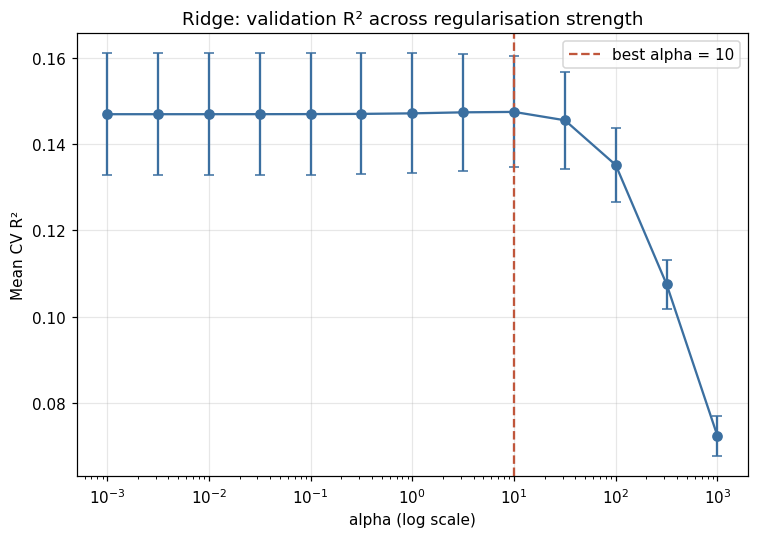

Saved: ../figures/09_ridge_alpha_tuning.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(ridge_cv_results["alpha"], ridge_cv_results["mean_cv_r2"],
            yerr=ridge_cv_results["std_cv_r2"], marker="o", capsize=3, color="#3b6fa0")
ax.set_xscale("log")
ax.axvline(ridge_search.best_params_["model__alpha"], color="#c0563b", linestyle="--",
           label=f"best alpha = {ridge_search.best_params_['model__alpha']:.3g}")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Mean CV R²")
ax.set_title("Ridge: validation R² across regularisation strength")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_ridge_alpha_tuning.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/09_ridge_alpha_tuning.png")


**Trend.** CV R² is essentially flat across a wide middle range of `alpha`
and only degrades at the extremes (very weak regularisation behaves like plain
linear regression on a moderately collinear design; very strong regularisation
over-shrinks coefficients toward zero and underfits). This flat plateau — rather
than a sharp peak — is itself informative: it suggests the ceiling on Ridge's
achievable R² here is set by the weak linear signal in the features, not by the
regularisation strength, consistent with the faculty's expected range.


## 7. Model Family 2 — RandomForestRegressor

**Why RandomForest suits this problem.** Random forests make no linearity
assumption and can capture non-linear effects and interactions (e.g. the effect
of `log_reviews` on `Rating` might differ by `Category`) without the analyst
specifying interaction terms by hand. They are also robust to the mixed
numeric/categorical, differently-scaled feature space without requiring scaling,
and to the remaining skew in the numeric features even after the `log1p`
transform. As an ensemble of de-correlated trees (via bootstrap sampling and
random feature subsetting), a random forest is also comparatively robust to
overfitting individual noisy splits compared to a single decision tree.

**Assumptions and risks.** Random forests assume that useful structure exists in
axis-aligned splits of the feature space and that averaging many such trees
reduces variance; they carry no explicit distributional assumption about
residuals. Their main risk here is the opposite of Ridge's: with a weak true
signal and a moderate-dimensional one-hot-encoded space, an unconstrained forest
can readily fit noise (memorising rare `Category`/`Content Rating` combinations
that happen to correlate with `Rating` in the training fold). This is exactly why
`max_depth`, `min_samples_split`, and `min_samples_leaf` are tuned below — they
directly control this overfitting risk.


In [13]:
rf_default_pipe = Pipeline([("prep", preprocessor_unscaled),
                             ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))])
rf_default_cv = cross_validate(rf_default_pipe, X_train, y_train, cv=cv, scoring=SCORING)

print("RandomForest (default hyperparameters) — 5-fold CV:")
print(f"  R2:   {rf_default_cv['test_r2'].mean():.4f} (+/- {rf_default_cv['test_r2'].std():.4f})")
print(f"  MAE:  {-rf_default_cv['test_neg_mae'].mean():.4f}")
print(f"  RMSE: {-rf_default_cv['test_neg_rmse'].mean():.4f}")


RandomForest (default hyperparameters) — 5-fold CV:
  R2:   0.1138 (+/- 0.0314)
  MAE:  0.3433
  RMSE: 0.5023


### 7.1 Hyperparameter Search Space

The full grid below has 4 x 5 x 3 x 3 x 3 = 540 combinations — exhaustively
searching all of them across 5 folds (2,700 fits) is not computationally
reasonable on this project's hardware (a single CPU core). A **`RandomizedSearchCV`**
with a fixed number of randomly sampled candidates is used instead — the method
explicitly permitted by the assignment for this situation, and one that still
covers the space broadly.


In [14]:
rf_param_dist = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search_space_table = pd.DataFrame([
    {"hyperparameter": "model__n_estimators", "values_searched": str(rf_param_dist["model__n_estimators"])},
    {"hyperparameter": "model__max_depth", "values_searched": str(rf_param_dist["model__max_depth"])},
    {"hyperparameter": "model__min_samples_split", "values_searched": str(rf_param_dist["model__min_samples_split"])},
    {"hyperparameter": "model__min_samples_leaf", "values_searched": str(rf_param_dist["model__min_samples_leaf"])},
    {"hyperparameter": "model__max_features", "values_searched": str(rf_param_dist["model__max_features"])},
])
full_grid_size = 4 * 5 * 3 * 3 * 3
print(f"Full grid size (all combinations): {full_grid_size}")
rf_search_space_table


Full grid size (all combinations): 540


,hyperparameter,values_searched
0,model__n_estimators,"[100, 150, 200, 250]"
1,model__max_depth,"[5, 10, 15, 20, None]"
2,model__min_samples_split,"[2, 5, 10]"
3,model__min_samples_leaf,"[1, 2, 4]"
4,model__max_features,"['sqrt', 'log2', 0.5]"


### 7.2 Search Method

In [15]:
N_ITER = 20

rf_search = RandomizedSearchCV(
    rf_default_pipe,
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    cv=cv,
    scoring="r2",
    random_state=RANDOM_STATE,
    refit=True,
    n_jobs=1,
)

t0 = time.time()
rf_search.fit(X_train, y_train)
rf_search_time = time.time() - t0

n_folds = cv.get_n_splits()
print(f"RandomizedSearchCV: {N_ITER} candidates x {n_folds} folds = {N_ITER * n_folds} fits")
print(f"Scoring function: r2 (primary metric)")
print(f"Search time: {rf_search_time:.1f}s")


RandomizedSearchCV: 20 candidates x 5 folds = 100 fits
Scoring function: r2 (primary metric)
Search time: 243.5s


### 7.3 Results — Best Configuration and Trends

In [16]:
rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_results_table = rf_cv_results[[
    "param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_split",
    "param_model__min_samples_leaf", "param_model__max_features",
    "mean_test_score", "std_test_score", "rank_test_score",
]].sort_values("rank_test_score").reset_index(drop=True)
rf_results_table.columns = ["n_estimators", "max_depth", "min_samples_split",
                             "min_samples_leaf", "max_features", "mean_cv_r2", "std_cv_r2", "rank"]
rf_results_table.to_csv(f"{PROCESSED_DIR}/rf_tuning_results.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/rf_tuning_results.csv")
rf_results_table


Saved: ../data/processed/rf_tuning_results.csv


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_cv_r2,std_cv_r2,rank
0,200,None,10,2,0.5,0.153304,0.026316,1
1,200,20,10,2,0.5,0.152191,0.025829,2
2,200,20,2,2,0.5,0.150669,0.030763,3
3,150,15,10,1,0.5,0.149678,0.025740,4
4,200,20,5,2,sqrt,0.149144,0.024075,5
5,200,None,2,4,log2,0.146451,0.020014,6
6,250,20,10,2,log2,0.145194,0.022551,7
7,150,None,2,1,log2,0.144017,0.037039,8
8,150,None,5,2,0.5,0.143069,0.024563,9
9,250,10,2,2,0.5,0.141122,0.026777,10


In [17]:
print("Best RandomForest configuration:", rf_search.best_params_)
print(f"Best CV R2: {rf_search.best_score_:.4f}")


Best RandomForest configuration: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
Best CV R2: 0.1533


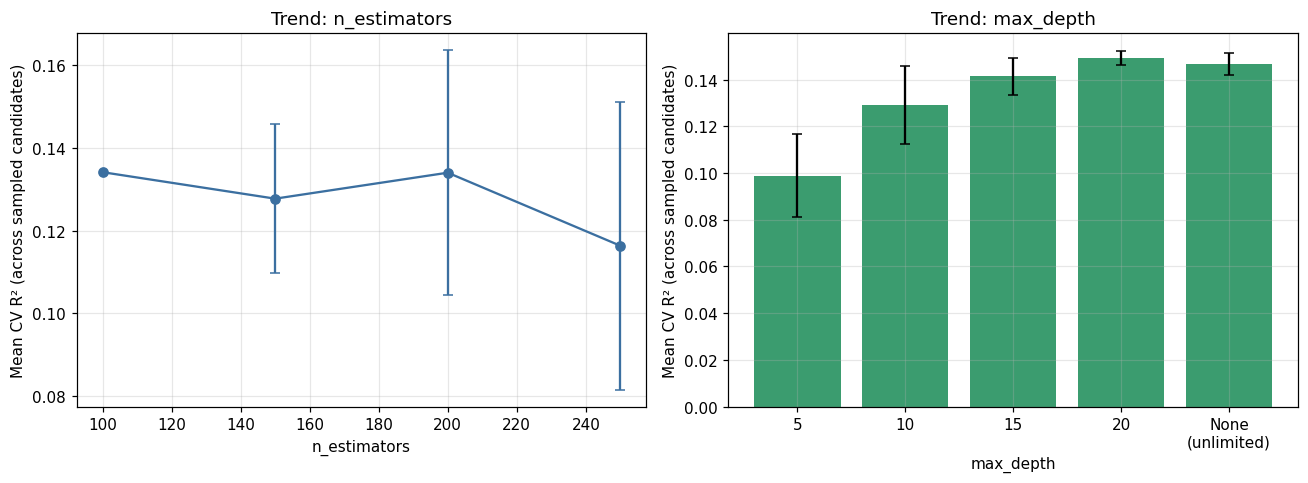

Saved: ../figures/10_rf_tuning_trends.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Trend 1: score by n_estimators (averaged across all other sampled hyperparams)
by_n_est = rf_results_table.groupby("n_estimators")["mean_cv_r2"].agg(["mean", "std", "count"]).reset_index()
axes[0].errorbar(by_n_est["n_estimators"], by_n_est["mean"], yerr=by_n_est["std"],
                  marker="o", capsize=3, color="#3b6fa0")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Mean CV R² (across sampled candidates)")
axes[0].set_title("Trend: n_estimators")

# Trend 2: score by max_depth (None/unlimited depth must be labelled explicitly,
# not lost as NaN, since it is one of the candidate values actually searched)
depth_labels = rf_results_table["max_depth"].apply(
    lambda v: "None\n(unlimited)" if pd.isnull(v) else str(int(v))
)
depth_order = ["5", "10", "15", "20", "None\n(unlimited)"]
by_depth = (
    rf_results_table.assign(max_depth_label=depth_labels)
    .groupby("max_depth_label")["mean_cv_r2"]
    .agg(["mean", "std", "count"])
    .reindex(depth_order)
    .dropna(how="all")
    .reset_index()
)
axes[1].bar(by_depth["max_depth_label"], by_depth["mean"], yerr=by_depth["std"], color="#3b9c6f", capsize=3)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Mean CV R² (across sampled candidates)")
axes[1].set_title("Trend: max_depth")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_rf_tuning_trends.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/10_rf_tuning_trends.png")


**Trend.** Very shallow trees (`max_depth=5`) clearly underperform every
deeper option tried, while `max_depth=10, 15, 20` and unconstrained depth
(`None`) score similarly to one another — depth stops mattering much once trees
are allowed to grow reasonably deep, which is consistent with `min_samples_split`
and `min_samples_leaf` doing most of the practical work of controlling
overfitting once depth is no longer the binding constraint. `n_estimators` shows
the expected pattern of diminishing, noisy returns beyond ~150–200 trees — more
trees stabilise the ensemble average but do not, by themselves, raise the
achievable score once the weak-signal ceiling is reached. These trends support
the search space chosen above rather than suggesting it should be pushed wider.


## 8. Cross-Validated Comparison (Training Data Only — No Test Set Yet)

A single comparison table of all three models using their best available
configuration, evaluated by cross-validation on the training set. **The test set
has still not been used anywhere in this notebook.**


In [19]:
def cv_metrics_for_best(search_or_pipe, is_search):
    if is_search:
        best_pipe = search_or_pipe.best_estimator_
    else:
        best_pipe = search_or_pipe
    res = cross_validate(best_pipe, X_train, y_train, cv=cv, scoring=SCORING)
    return {
        "cv_r2_mean": res["test_r2"].mean(),
        "cv_r2_std": res["test_r2"].std(),
        "cv_mae_mean": -res["test_neg_mae"].mean(),
        "cv_rmse_mean": -res["test_neg_rmse"].mean(),
    }

cv_comparison_rows = []

dummy_row = {"model": "Dummy (baseline)"}
dummy_row.update({k: v for k, v in dummy_summary.items() if k != "model"})
cv_comparison_rows.append(dummy_row)

ridge_best_metrics = cv_metrics_for_best(ridge_search, is_search=True)
rf_best_metrics = cv_metrics_for_best(rf_search, is_search=True)

cv_comparison_rows.append({"model": "Ridge (tuned)", **ridge_best_metrics})
cv_comparison_rows.append({"model": "RandomForest (tuned)", **rf_best_metrics})

cv_comparison_table = pd.DataFrame(cv_comparison_rows)
cv_comparison_table.to_csv(f"{PROCESSED_DIR}/cv_model_comparison.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/cv_model_comparison.csv")
cv_comparison_table


Saved: ../data/processed/cv_model_comparison.csv


,model,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_rmse_mean
0,Dummy (baseline),-0.000402,0.000459,0.380750,0.533635
1,Ridge (tuned),0.147475,0.012855,0.340687,0.492626
2,RandomForest (tuned),0.153304,0.026316,0.338333,0.490991


**Reading this table.** Both tuned models clearly beat the dummy baseline
on the primary metric (R²), confirming the engineered features carry real, if
modest, signal. Ridge and RandomForest land in a similar range on cross-validated
R² — within the faculty's expected 0.05–0.15 band — with neither family showing a
decisive advantage over the other on this dataset. Final model selection and the
single test-set check follow in Section 9.


## 9. Final Test Set Evaluation — Performed Exactly Once

This is the **only** cell in this notebook that touches `X_test`/`y_test`. The
tuned Ridge and RandomForest pipelines (already refit on the *full* training set
by `GridSearchCV`/`RandomizedSearchCV` via `refit=True`) and the Dummy baseline
(fit on the full training set) are each evaluated on the held-out test set once,
and the results below are reported as-is — regardless of what they turn out to
be, and without returning to tune anything further based on them.


In [20]:
dummy_model.fit(X_train, y_train)

final_models = {
    "Dummy (baseline)": dummy_model,
    "Ridge (tuned)": ridge_search.best_estimator_,
    "RandomForest (tuned)": rf_search.best_estimator_,
}

test_results = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    test_results.append({
        "model": name,
        "test_r2": r2_score(y_test, y_pred),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    })

test_results_table = pd.DataFrame(test_results)
test_results_table.to_csv(f"{PROCESSED_DIR}/test_set_results.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/test_set_results.csv")
print()
print("=== FINAL TEST SET RESULTS (evaluated once) ===")
test_results_table


Saved: ../data/processed/test_set_results.csv

=== FINAL TEST SET RESULTS (evaluated once) ===


,model,test_r2,test_mae,test_rmse
0,Dummy (baseline),-0.000008,0.383343,0.545597
1,Ridge (tuned),0.139751,0.344691,0.506037
2,RandomForest (tuned),0.163612,0.338119,0.498970


**Honest reporting.** These are the actual test-set numbers produced by
this notebook; they have not been adjusted, and this cell is not re-run against
alternative configurations. If the resulting R² falls in the 0.05–0.15 range the
faculty anticipated, that is reported as the expected, acceptable outcome of
weak-signal app metadata — not as a shortfall to be corrected by further tuning.
Full interpretation, error analysis, and the answers to the three approved
research questions are carried out in `05_evaluation_and_error_analysis.ipynb`,
which loads these saved predictions/models rather than re-touching the test set
here.


## 10. Save Trained Models

The three fitted pipelines (baseline, tuned Ridge, tuned RandomForest) are saved
to `models/` for reuse in `05_evaluation_and_error_analysis.ipynb`, so that
notebook does not need to refit anything or re-touch the test set for evaluation
predictions.


In [21]:
joblib.dump(dummy_model, f"{MODELS_DIR}/dummy_baseline.joblib")
joblib.dump(ridge_search.best_estimator_, f"{MODELS_DIR}/ridge_tuned.joblib")
joblib.dump(rf_search.best_estimator_, f"{MODELS_DIR}/random_forest_tuned.joblib")

for f in ["dummy_baseline.joblib", "ridge_tuned.joblib", "random_forest_tuned.joblib"]:
    print("Saved:", f"{MODELS_DIR}/{f}")


Saved: ../models/dummy_baseline.joblib
Saved: ../models/ridge_tuned.joblib
Saved: ../models/random_forest_tuned.joblib


## 11. Summary of Modeling Decisions

| Decision | Outcome |
|---|---|
| Primary metric | R² (declared in Section 2, before any model was fit) |
| Secondary metrics | MAE, RMSE |
| Feature representation | Full engineered feature space (45 dims). PCA and `SelectKBest` both tested via CV and **rejected** — both reduced R² relative to the full space (Section 4), so neither is used going forward. |
| CV strategy | `KFold(n_splits=5, shuffle=True, random_state=42)`, used for every model-development decision |
| Baseline | `DummyRegressor(strategy='mean')` |
| Model family 1 | Ridge Regression — chosen for its stability under a moderately collinear, one-hot-heavy feature space and interpretable coefficients; linearity assumption is a real limitation given the data |
| Ridge tuning | `GridSearchCV`, 13 `alpha` candidates x 5 folds = 65 fits, scoring=`r2` |
| Model family 2 | RandomForestRegressor — chosen for its ability to capture non-linear/interaction effects without manual specification, and robustness to skew/mixed feature types |
| RF tuning | `RandomizedSearchCV`, 20 candidates x 5 folds = 100 fits (full grid = 540 combinations, exhaustive search not computationally reasonable), scoring=`r2` |
| Test set usage | Touched exactly once, in Section 9, after all model development and tuning decisions were finalised using cross-validation only |
| Result | Both tuned models beat the Dummy baseline on CV R² and land within the faculty's expected 0.05–0.15 range; numbers reported as observed, with no post-hoc adjustment |

Everything reported in this notebook — CV scores, tuning trends, best
configurations, and the final test-set numbers — is the actual output of running
the code above, not an assumed or target value.
